In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

import os
import csv

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA Tegra X1


In [2]:
class SteeringDataset(Dataset):
    def __init__(self, csv_path, images_dir, transform=None):
        self.images_dir = images_dir
        self.transform = transform

        with open(csv_path, "r") as f:
            reader = csv.reader(f)
            self.samples = list(reader)[1:]  # מדלגים על הכותרת

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filename, steering = self.samples[idx]

        image_path = os.path.join(
            self.images_dir,
            filename
        )

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        steering = torch.tensor(
            float(steering),
            dtype=torch.float32
        )

        return image, steering


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


images_dir = "datasets/clockwise/images"
csv_path = "datasets/clockwise/labels.csv"

dataset = SteeringDataset(
    csv_path,
    images_dir,
    transform
)

print("Total samples:", len(dataset))

Total samples: 1573


In [3]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Train samples: 1258
Validation samples: 315


In [4]:
class SteeringCNN(nn.Module):
    def __init__(self):
        super(SteeringCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=5, stride=2),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=5, stride=2),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x.squeeze(1)


model = SteeringCNN().to(device)

print(model)
print("\nModel created on:", device)

SteeringCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(2, 2))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(5, 5), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2))
    (5): ReLU()
    (6): AdaptiveAvgPool2d(output_size=(4, 4))
  )
  (regressor): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1024, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)

Model created on: cuda


In [5]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

num_epochs = 20

print("Loss: MSELoss")
print("Optimizer: Adam")
print("Learning rate: 0.001")
print("Epochs:", num_epochs)

Loss: MSELoss
Optimizer: Adam
Learning rate: 0.001
Epochs: 20


In [6]:
os.makedirs("models", exist_ok=True)

best_val_loss = float("inf")

for epoch in range(num_epochs):

    # ===== TRAIN =====
    model.train()
    train_loss = 0.0

    for images, steering_values in train_loader:

        images = images.to(device)
        steering_values = steering_values.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, steering_values)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_loader.dataset)


    # ===== VALIDATION =====
    model.eval()
    val_loss = 0.0

    with torch.no_grad():

        for images, steering_values in val_loader:

            images = images.to(device)
            steering_values = steering_values.to(device)

            outputs = model(images)

            loss = criterion(outputs, steering_values)

            val_loss += loss.item() * images.size(0)

    val_loss /= len(val_loader.dataset)


    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )


    # ===== SAVE BEST MODEL =====
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "models/clockwise_steering_best.pth"
        )

        print("-> Best model saved")


print("\nTraining finished!")
print("Best Val Loss:", best_val_loss)

Epoch 1/10 | Train Loss: 0.003381 | Val Loss: 0.001916
-> Best model saved
Epoch 2/10 | Train Loss: 0.003151 | Val Loss: 0.001924
Epoch 3/10 | Train Loss: 0.003023 | Val Loss: 0.002150
Epoch 4/10 | Train Loss: 0.003069 | Val Loss: 0.002048
Epoch 5/10 | Train Loss: 0.002930 | Val Loss: 0.001783
-> Best model saved
Epoch 6/10 | Train Loss: 0.002723 | Val Loss: 0.001803
Epoch 7/10 | Train Loss: 0.002571 | Val Loss: 0.001666
-> Best model saved
Epoch 8/10 | Train Loss: 0.002425 | Val Loss: 0.001929
Epoch 9/10 | Train Loss: 0.003253 | Val Loss: 0.001677
Epoch 10/10 | Train Loss: 0.002753 | Val Loss: 0.001697

Training finished!
Best Val Loss: 0.0016655430443725497


In [6]:
best_val_loss = float("inf")

model_path = "models/clockwise_steering_1573_best.pth"

for epoch in range(num_epochs):

    # =========================
    # TRAIN
    # =========================

    model.train()

    train_loss = 0.0

    for images, steering in train_loader:

        images = images.to(device)
        steering = steering.to(device)

        optimizer.zero_grad()

        predictions = model(images)

        loss = criterion(predictions, steering)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_loader.dataset)


    # =========================
    # VALIDATION
    # =========================

    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for images, steering in val_loader:

            images = images.to(device)
            steering = steering.to(device)

            predictions = model(images)

            loss = criterion(predictions, steering)

            val_loss += loss.item() * images.size(0)

    val_loss /= len(val_loader.dataset)


    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )


    # =========================
    # SAVE BEST MODEL
    # =========================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            model_path
        )

        print("  -> Best model saved!")


print("\nTraining finished.")
print("Best Val Loss:", best_val_loss)
print("Saved as:", model_path)

Epoch 1/20 | Train Loss: 0.004375 | Val Loss: 0.003737
  -> Best model saved!
Epoch 2/20 | Train Loss: 0.003777 | Val Loss: 0.003695
  -> Best model saved!
Epoch 3/20 | Train Loss: 0.003616 | Val Loss: 0.003525
  -> Best model saved!
Epoch 4/20 | Train Loss: 0.003518 | Val Loss: 0.003414
  -> Best model saved!
Epoch 5/20 | Train Loss: 0.003535 | Val Loss: 0.003242
  -> Best model saved!
Epoch 6/20 | Train Loss: 0.003192 | Val Loss: 0.003096
  -> Best model saved!
Epoch 7/20 | Train Loss: 0.003187 | Val Loss: 0.003183
Epoch 8/20 | Train Loss: 0.003310 | Val Loss: 0.003597
Epoch 9/20 | Train Loss: 0.003379 | Val Loss: 0.003311
Epoch 10/20 | Train Loss: 0.003270 | Val Loss: 0.003092
  -> Best model saved!
Epoch 11/20 | Train Loss: 0.003053 | Val Loss: 0.003107
Epoch 12/20 | Train Loss: 0.003075 | Val Loss: 0.003008
  -> Best model saved!
Epoch 13/20 | Train Loss: 0.002856 | Val Loss: 0.003620
Epoch 14/20 | Train Loss: 0.002869 | Val Loss: 0.002827
  -> Best model saved!
Epoch 15/20 | Trai

In [7]:
model.load_state_dict(
    torch.load(
        "models/clockwise_steering_best.pth",
        map_location=device
    )
)

model.eval()

print("Best clockwise model loaded!")

Best clockwise model loaded!


In [7]:
model.load_state_dict(
    torch.load(
        "models/clockwise_steering_1573_best.pth",
        map_location=device
    )
)

model.eval()

print("Best 1573 model loaded!")

Best 1573 model loaded!


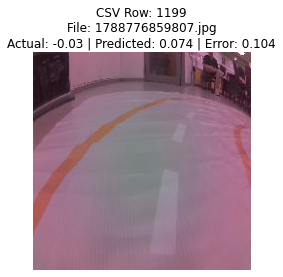

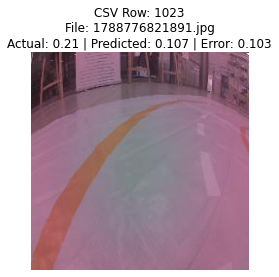

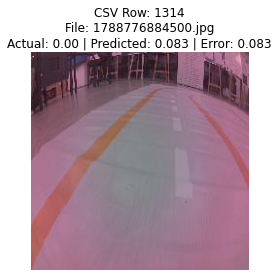

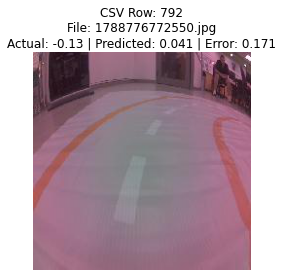

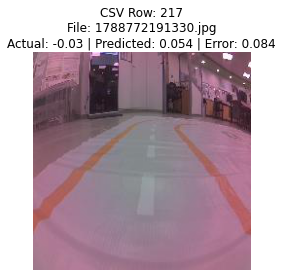

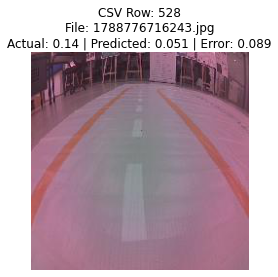

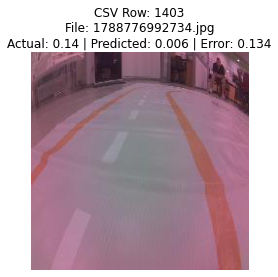

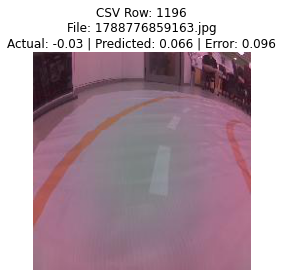

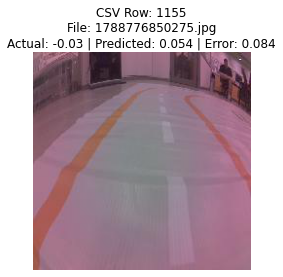

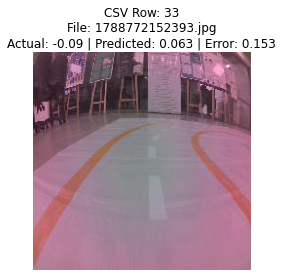

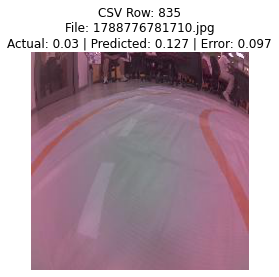

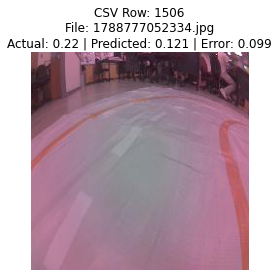

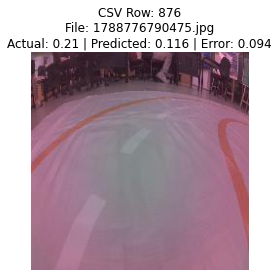

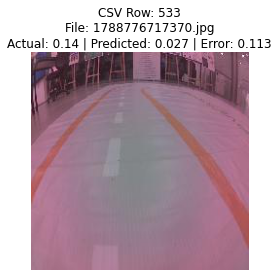

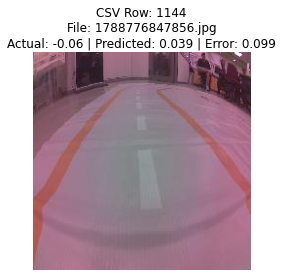

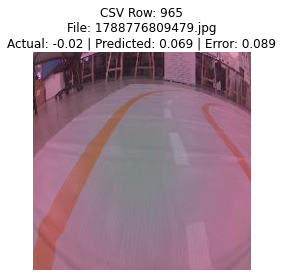

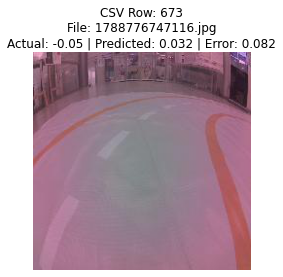

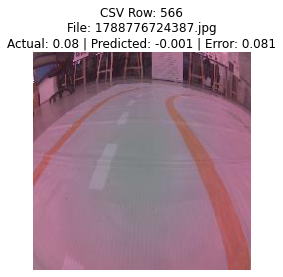

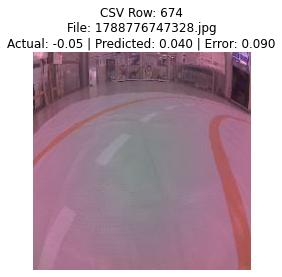

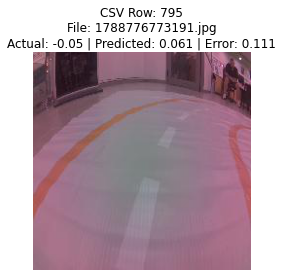

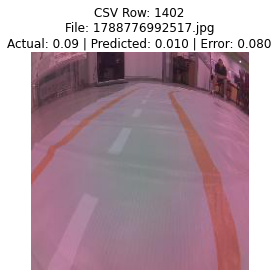

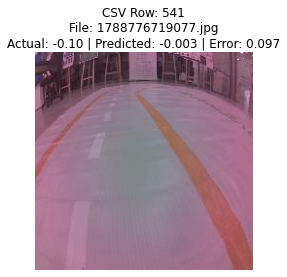

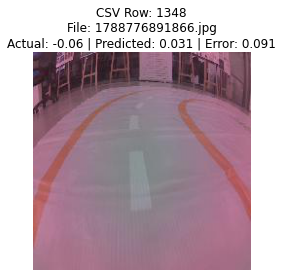

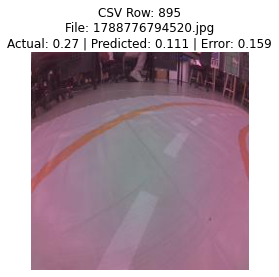

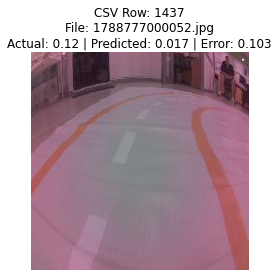

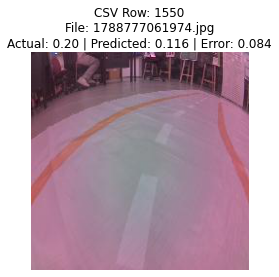

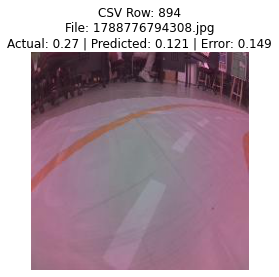

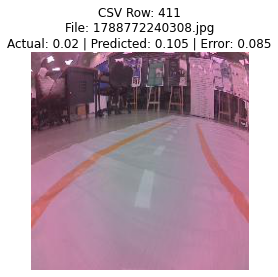

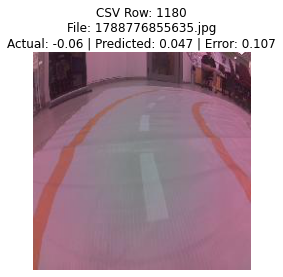

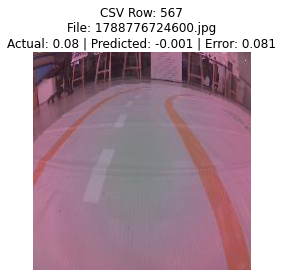

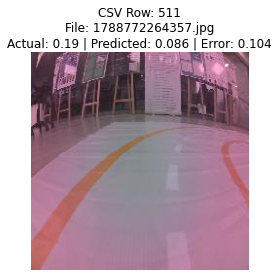

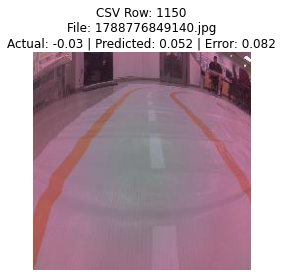

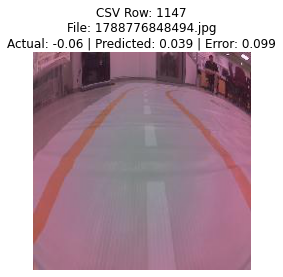

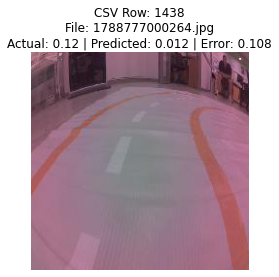

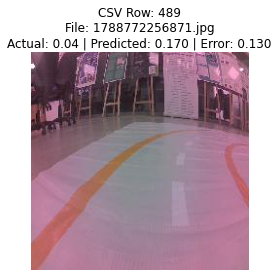

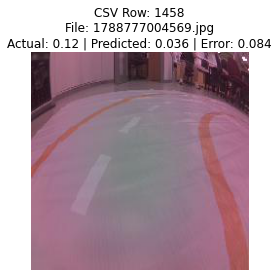

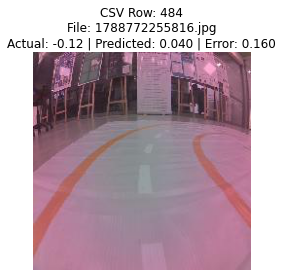

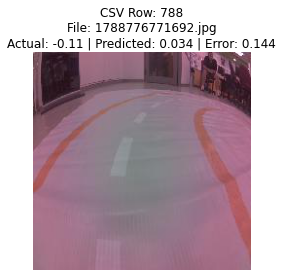

In [8]:
import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():

    for i in range(len(val_dataset)):

        image, actual = val_dataset[i]

        input_image = image.unsqueeze(0).to(device)
        predicted = model(input_image).item()

        actual_value = actual.item()
        error = abs(actual_value - predicted)

        # מציג תמונות עם שגיאה משמעותית
        if error > 0.08:

            # האינדקס המקורי בתוך ה-Dataset
            original_index = val_dataset.indices[i]

            # שם התמונה
            filename = dataset.samples[original_index][0]

            # מספר השורה האמיתי ב-labels.csv
            # +1 בגלל index שמתחיל ב-0
            # +1 בגלל שורת הכותרת
            csv_row = original_index + 2

            # הכנת התמונה להצגה
            img = image.permute(1, 2, 0).cpu().numpy()

            plt.figure(figsize=(6, 4))
            plt.imshow(img)
            plt.axis("off")

            plt.title(
                f"CSV Row: {csv_row}\n"
                f"File: {filename}\n"
                f"Actual: {actual_value:.2f} | "
                f"Predicted: {predicted:.3f} | "
                f"Error: {error:.3f}"
            )

            plt.show()

In [9]:
wrong_direction = 0
total_nonzero = 0

model.eval()

with torch.no_grad():
    for i in range(len(val_dataset)):

        image, actual = val_dataset[i]

        predicted = model(
            image.unsqueeze(0).to(device)
        ).item()

        actual_value = actual.item()

        if actual_value != 0:
            total_nonzero += 1

            if (
                (actual_value > 0 and predicted < 0) or
                (actual_value < 0 and predicted > 0)
            ):
                wrong_direction += 1

print("Validation samples:", len(val_dataset))
print("Non-zero steering:", total_nonzero)
print("Wrong direction:", wrong_direction)

if total_nonzero > 0:
    print(
        "Wrong direction %:",
        round(100 * wrong_direction / total_nonzero, 2),
        "%"
    )

Validation samples: 315
Non-zero steering: 303
Wrong direction: 31
Wrong direction %: 10.23 %


In [10]:
model.eval()

print("Strong RIGHT samples")
print("--------------------")

count = 0

with torch.no_grad():

    for i in range(len(val_dataset)):

        image, actual = val_dataset[i]

        actual_value = actual.item()

        # רק פניות ימינה משמעותיות
        if actual_value >= 0.10:

            predicted = model(
                image.unsqueeze(0).to(device)
            ).item()

            print(
                f"Actual: {actual_value:+.3f} | "
                f"Predicted: {predicted:+.3f}"
            )

            count += 1

            if count >= 20:
                break

Strong RIGHT samples
--------------------
Actual: +0.120 | Predicted: +0.139
Actual: +0.210 | Predicted: +0.107
Actual: +0.100 | Predicted: +0.071
Actual: +0.110 | Predicted: +0.074
Actual: +0.100 | Predicted: +0.119
Actual: +0.160 | Predicted: +0.109
Actual: +0.160 | Predicted: +0.096
Actual: +0.140 | Predicted: +0.092
Actual: +0.100 | Predicted: +0.073
Actual: +0.140 | Predicted: +0.051
Actual: +0.120 | Predicted: +0.049
Actual: +0.160 | Predicted: +0.114
Actual: +0.120 | Predicted: +0.107
Actual: +0.110 | Predicted: +0.131
Actual: +0.140 | Predicted: +0.089
Actual: +0.150 | Predicted: +0.157
Actual: +0.190 | Predicted: +0.114
Actual: +0.150 | Predicted: +0.096
Actual: +0.140 | Predicted: +0.006
Actual: +0.150 | Predicted: +0.100


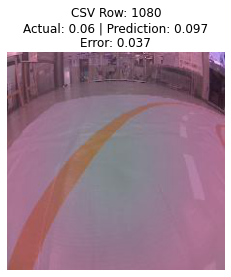

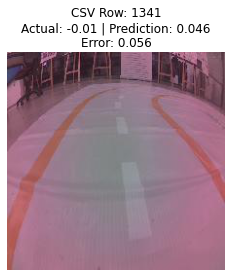

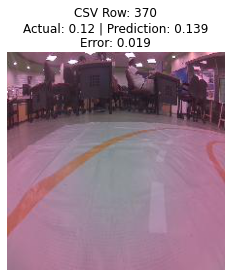

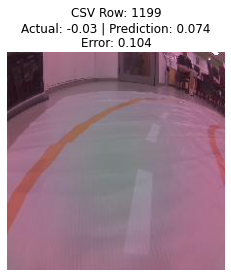

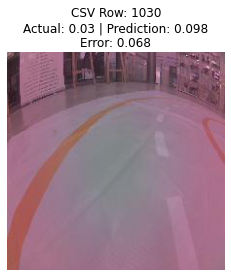

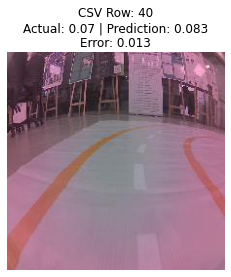

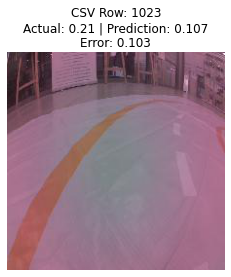

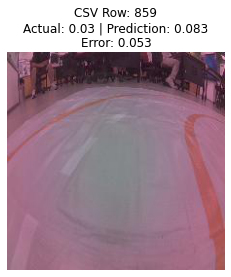

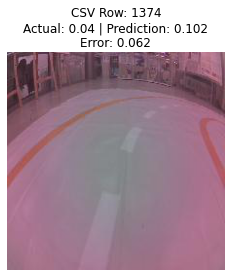

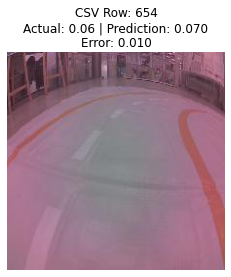

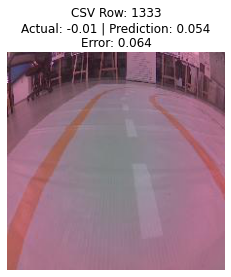

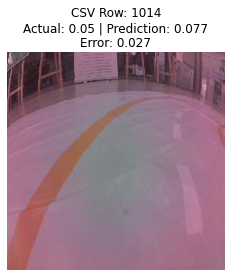

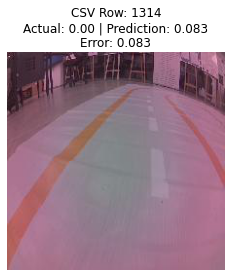

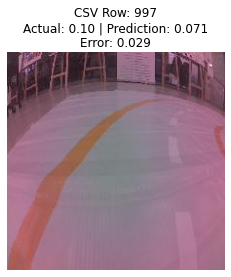

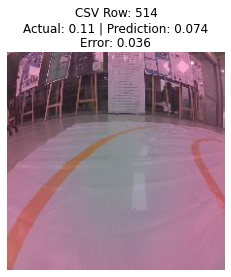

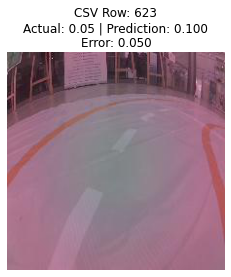

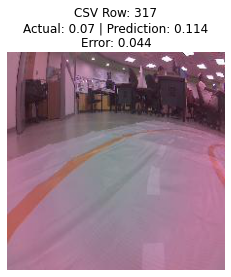

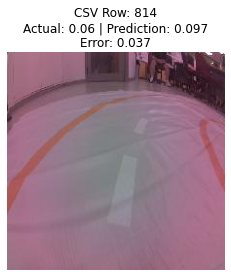

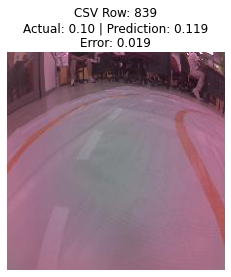

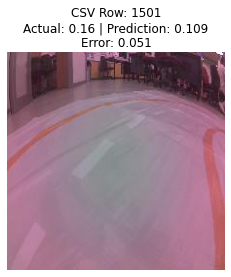

In [11]:
import matplotlib.pyplot as plt

model.eval()

# כמה תמונות להציג
num_images = 20

with torch.no_grad():

    for i in range(min(num_images, len(val_dataset))):

        image, actual = val_dataset[i]

        predicted = model(
            image.unsqueeze(0).to(device)
        ).item()

        actual_value = actual.item()
        error = abs(actual_value - predicted)

        original_index = val_dataset.indices[i]
        filename = dataset.samples[original_index][0]
        csv_row = original_index + 2

        img = image.permute(1, 2, 0).cpu().numpy()

        plt.figure(figsize=(5, 4))
        plt.imshow(img)
        plt.axis("off")

        plt.title(
            f"CSV Row: {csv_row}\n"
            f"Actual: {actual_value:.2f} | "
            f"Prediction: {predicted:.3f}\n"
            f"Error: {error:.3f}"
        )

        plt.show()

In [10]:
from jetbot import Camera

camera = Camera.instance(
    width=224,
    height=224
)

print("Camera ready!")

Camera ready!


In [12]:
camera.stop()
print("Camera stopped")

Camera stopped


In [13]:
import torch
import torch.nn as nn

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

class SteeringCNN(nn.Module):
    def __init__(self):
        super(SteeringCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=5, stride=2),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=5, stride=2),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x.squeeze(1)


model = SteeringCNN().to(device)

model.load_state_dict(
    torch.load(
        "models/clockwise_steering_best.pth",
        map_location=device
    )
)

model.eval()

print("Clockwise model loaded!")
print("Device:", device)

Clockwise model loaded!
Device: cuda


In [ ]:
from jetbot import Camera

camera = Camera.instance(
    width=224,
    height=224
)

print("Camera ready!")

In [14]:
import time
import threading
import ipywidgets as widgets
import traitlets

from PIL import Image
from torchvision import transforms
from jetbot import bgr8_to_jpeg
from IPython.display import display


# אותה הכנה לתמונה שבה השתמשנו באימון
live_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


# תצוגת מצלמה
camera_view = widgets.Image(
    format="jpeg",
    width=400,
    height=300
)

camera_link = traitlets.dlink(
    (camera, "value"),
    (camera_view, "value"),
    transform=bgr8_to_jpeg
)


# תצוגת Prediction
prediction_label = widgets.Label(
    value="Prediction: ---"
)

prediction_running = False


def prediction_loop():
    global prediction_running

    while prediction_running:

        image_bgr = camera.value

        if image_bgr is None:
            time.sleep(0.05)
            continue

        # BGR -> RGB
        image_rgb = image_bgr[:, :, ::-1].copy()

        pil_image = Image.fromarray(image_rgb)

        input_tensor = (
            live_transform(pil_image)
            .unsqueeze(0)
            .to(device)
        )

        with torch.no_grad():
            prediction = model(input_tensor).item()

        prediction_label.value = (
            f"Prediction: {prediction:.3f}"
        )

        time.sleep(0.05)


def start_prediction(b):
    global prediction_running

    if prediction_running:
        return

    prediction_running = True

    threading.Thread(
        target=prediction_loop,
        daemon=True
    ).start()


def stop_prediction(b):
    global prediction_running
    prediction_running = False


start_button = widgets.Button(
    description="START PREDICTION"
)

stop_button = widgets.Button(
    description="STOP PREDICTION"
)

start_button.on_click(start_prediction)
stop_button.on_click(stop_prediction)


display(camera_view)
display(prediction_label)
display(
    widgets.HBox([
        start_button,
        stop_button
    ])
)

Image(value=b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x02\x01\x0…

Label(value='Prediction: ---')

In [15]:
camera.stop()
print("Camera stopped")

Camera stopped
